<a href="https://colab.research.google.com/github/jaison-03/23_9_26_git/blob/main/Sentiment_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
pip install pandas numpy matplotlib seaborn scikit-learn nltk

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import nltk
import re

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

In [4]:
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


True

In [7]:
stop_words = stopwords.words('english')

In [8]:
data = {
    "text": [
        "I love this product",
        "This product is amazing",
        "The service was excellent",
        "I really enjoyed the movie",
        "The food was delicious",
        "This is a wonderful experience",
        "I hate this product",
        "This product is terrible",
        "The service was horrible",
        "I disliked the movie",
        "The food was disgusting",
        "This was a bad experience",
        "The product is okay",
        "The movie was average",
        "The service was normal"
    ],

    "sentiment": [
        "positive",
        "positive",
        "positive",
        "positive",
        "positive",
        "positive",
        "negative",
        "negative",
        "negative",
        "negative",
        "negative",
        "negative",
        "neutral",
        "neutral",
        "neutral"
    ]
}

df = pd.DataFrame(data)

print(df)

                              text sentiment
0              I love this product  positive
1          This product is amazing  positive
2        The service was excellent  positive
3       I really enjoyed the movie  positive
4           The food was delicious  positive
5   This is a wonderful experience  positive
6              I hate this product  negative
7         This product is terrible  negative
8         The service was horrible  negative
9             I disliked the movie  negative
10         The food was disgusting  negative
11       This was a bad experience  negative
12             The product is okay   neutral
13           The movie was average   neutral
14          The service was normal   neutral


In [9]:
print(df.head())

                         text sentiment
0         I love this product  positive
1     This product is amazing  positive
2   The service was excellent  positive
3  I really enjoyed the movie  positive
4      The food was delicious  positive


In [10]:
print(df.shape)

(15, 2)


In [11]:
print(df.columns)

Index(['text', 'sentiment'], dtype='object')


In [12]:
print(df.isnull().sum())

text         0
sentiment    0
dtype: int64


In [13]:
print(df["sentiment"].value_counts())

sentiment
positive    6
negative    6
neutral     3
Name: count, dtype: int64


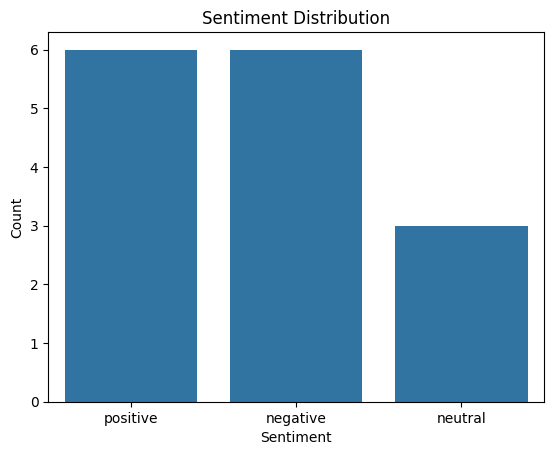

In [14]:
sns.countplot(data=df, x="sentiment")

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")

plt.show()

In [15]:
def clean_text(text):

    # Convert to lowercase
    text = text.lower()

    # Remove punctuation and special characters
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    return text

In [16]:
text = "I LOVE this product!!!"

print(clean_text(text))

i love this product


In [17]:
def tokenize(text):
    return text.split()

In [18]:
text = "I love this product"

tokens = tokenize(text)

print(tokens)

['I', 'love', 'this', 'product']


In [19]:
stop_words = set(stopwords.words("english"))

print(list(stop_words)[:20])

["she's", 'themselves', "she'd", 'did', 'couldn', 'when', 'if', 'these', 'won', 'few', 'both', 'y', 'again', 'nor', 'very', "don't", 'such', 'further', "they've", "i'll"]


In [20]:
lemmatizer = WordNetLemmatizer()

In [21]:
def lemmatize_words(tokens):

    lemmatized = []

    for word in tokens:
        lemmatized.append(lemmatizer.lemmatize(word))

    return lemmatized

In [22]:
words = ["cars", "dogs", "books"]

print(lemmatize_words(words))

['car', 'dog', 'book']


In [28]:
def preprocess_text(text):

    # Lowercase
    text = text.lower()

    # Remove special characters
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # Tokenization
    tokens = text.split()

    # Stopword removal
    tokens = [
        word for word in tokens
        if word not in stop_words
    ]

    # Lemmatization
    tokens = [
        lemmatizer.lemmatize(word)
        for word in tokens
    ]

    return " ".join(tokens)

In [32]:
text = "I really loved these amazing products!"

result = preprocess_text(text)

print(result)

really loved amazing product


In [29]:
df["clean_text"] = df["text"].apply(preprocess_text)

In [30]:
print(df[["text", "clean_text", "sentiment"]])

                              text            clean_text sentiment
0              I love this product          love product  positive
1          This product is amazing       product amazing  positive
2        The service was excellent     service excellent  positive
3       I really enjoyed the movie  really enjoyed movie  positive
4           The food was delicious        food delicious  positive
5   This is a wonderful experience  wonderful experience  positive
6              I hate this product          hate product  negative
7         This product is terrible      product terrible  negative
8         The service was horrible      service horrible  negative
9             I disliked the movie        disliked movie  negative
10         The food was disgusting       food disgusting  negative
11       This was a bad experience        bad experience  negative
12             The product is okay          product okay   neutral
13           The movie was average         movie average   neu

In [33]:
vectorizer = CountVectorizer()

X_bow = vectorizer.fit_transform(df["clean_text"])

In [35]:
print(vectorizer.get_feature_names_out())

['amazing' 'average' 'bad' 'delicious' 'disgusting' 'disliked' 'enjoyed'
 'excellent' 'experience' 'food' 'hate' 'horrible' 'love' 'movie' 'normal'
 'okay' 'product' 'really' 'service' 'terrible' 'wonderful']


In [36]:
print(X_bow.toarray())

[[0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 1 0 0 0 0]
 [1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0]
 [0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 1 0 0]
 [0 0 0 0 0 0 1 0 0 0 0 0 0 1 0 0 0 1 0 0 0]
 [0 0 0 1 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 1]
 [0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 1 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 1 0]
 [0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 1 0 0]
 [0 0 0 0 0 1 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0]
 [0 0 0 0 1 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 1 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 0 0 0 0]
 [0 1 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 1 0 0]]


In [38]:
tfidf = TfidfVectorizer()

X_tfidf = tfidf.fit_transform(df["clean_text"])

In [39]:
print(tfidf.get_feature_names_out())

['amazing' 'average' 'bad' 'delicious' 'disgusting' 'disliked' 'enjoyed'
 'excellent' 'experience' 'food' 'hate' 'horrible' 'love' 'movie' 'normal'
 'okay' 'product' 'really' 'service' 'terrible' 'wonderful']


In [40]:
print(X_tfidf.toarray())

[[0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.84103082 0.         0.         0.         0.5409872  0.
  0.         0.         0.        ]
 [0.84103082 0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.5409872  0.
  0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.79044896 0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.61252791 0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.62011552 0.         0.         0.         0.         0.
  0.         0.48053459 0.         0.         0.         0.62011552
  0.         0.         0.        ]
 [0.         0.         0.         0.75506655 0.         0.
  0.         0.         0.         0.65564815 0.         0.
  0.    

In [41]:
X = df["clean_text"]

y = df["sentiment"]

In [42]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [56]:
tfidf = TfidfVectorizer()

X_train_tfidf = tfidf.fit_transform(X_train)

X_test_tfidf = tfidf.transform(X_test)

In [47]:
model = LogisticRegression()

model.fit(X_train_tfidf, y_train)

LogisticRegression()

In [57]:
y_pred = model.predict(X_test_tfidf)

print(y_pred)

['positive' 'negative' 'negative']


In [58]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.0


In [59]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

    negative       0.00      0.00      0.00       1.0
     neutral       0.00      0.00      0.00       1.0
    positive       0.00      0.00      0.00       1.0

    accuracy                           0.00       3.0
   macro avg       0.00      0.00      0.00       3.0
weighted avg       0.00      0.00      0.00       3.0



/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [60]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[0 0 1]
 [1 0 0]
 [1 0 0]]


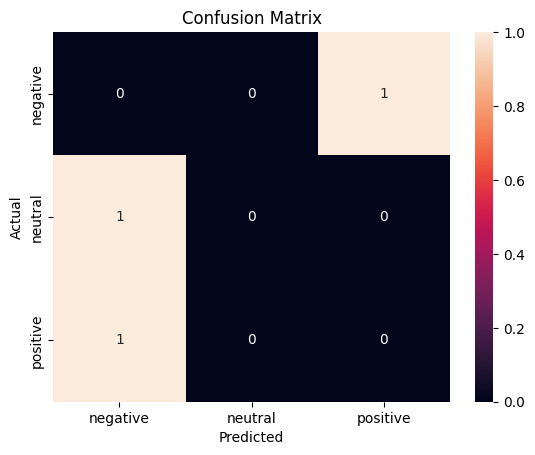

In [61]:
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=model.classes_,
    yticklabels=model.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [62]:
def predict_sentiment(text):

    cleaned = preprocess_text(text)

    vector = tfidf.transform([cleaned])

    prediction = model.predict(vector)[0]

    probability = model.predict_proba(vector)[0]

    return prediction, probability

In [63]:
text = "I really love this product"

sentiment, probability = predict_sentiment(text)

print("Text:", text)
print("Sentiment:", sentiment)
print("Probability:", probability)

Text: I really love this product
Sentiment: positive
Probability: [0.32350696 0.11759791 0.55889513]


In [64]:
sentences = [
    "I love this product",
    "This is a terrible product",
    "The product is okay",
    "Amazing experience",
    "I hate this service"
]

for sentence in sentences:

    sentiment, probability = predict_sentiment(sentence)

    print("\nText:", sentence)
    print("Sentiment:", sentiment)


Text: I love this product
Sentiment: positive

Text: This is a terrible product
Sentiment: negative

Text: The product is okay
Sentiment: negative

Text: Amazing experience
Sentiment: positive

Text: I hate this service
Sentiment: negative
